# Module 11: Raster Analysis


## Learning Objectives

After this lesson, you will be able to:
- Perform raster classification
- Conduct terrain analysis, such as calculating slope from DEM
- Perform raster calculations using map algebra

## Raster reclassification

Raster reclassification is the process of assigning new values to the pixels of a raster dataset based on their existing values. This is often used to simplify or categorize continuous data, such as elevation or land cover, into distinct classes. For example, in an elevation map, reclassification can group different elevation ranges into categories like "low", "medium", and "high" altitude, making it easier to analyze or visualize the data for specific applications such as hazard assessment or land management.

let's first have a look at the range of elevation values:

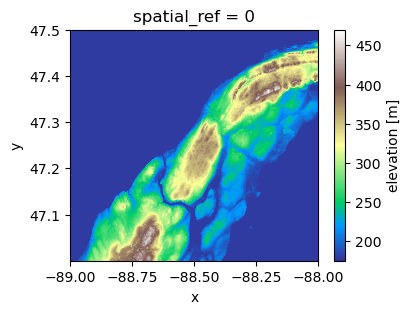

In [1]:
import xarray as xr

# read in the DEM file as a xarray Dataset
data = xr.open_dataset('data/n47_w089_1arc_v3.tif', engine="rasterio")

# remove the band dimension, because it only has 1
data = data.squeeze("band", drop=True)

# rename the data variable from band_data to elevation
data = data.rename({"band_data": "elevation"})

# slice the Dataset for the region of interest
data = data.sel(x=slice(-89, -88), y=slice(47.5, 47))

# Calculate a new variable : relative_height
data["relative_height"] = data["elevation"] - data["elevation"].min().item()

# visualize the elevation variable
data["elevation"].plot(cmap="terrain",figsize=(4,3))

Now we want to reclassify the data using two approaches. First, let's do it manually using the numpy library. [NumPy](https://numpy.org/doc/) is a powerful Python library used for numerical and scientific computing. It provides support for large, multi-dimensional arrays and matrices, along with a wide collection of mathematical functions to operate on arrays efficiently. So we are treating our pixel values as an Array and perform the calculations accordingly.

An array (such as those created by NumPy) is a multi-dimensional container for data, but it lacks metadata like coordinate labels or attributes. In contrast, an xarray.DataArray enhances the array by adding labeled dimensions, coordinates, and attributes, making it easier to work with multi-dimensional data, especially in geospatial and time-series contexts.

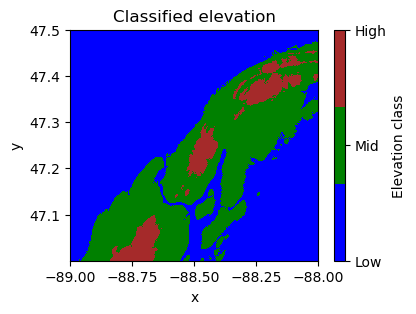

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# read the elevation DataArray from the DataSet
elev = data['elevation']

# Define the bins and new class values
bins = [-np.inf, 200, 350, np.inf]  # Bins for elevation, in meters
new_values = [1, 2, 3]  # Class values

# Mask out NaN values before reclassification
masked_raster = np.where(~np.isnan(elev), elev, np.nan)

# Apply the reclassification
reclassified_raster = np.digitize(masked_raster, bins, right=True)

# Retain NaN values by ensuring they are not reclassified
reclassified_raster = np.where(~np.isnan(elev), reclassified_raster, np.nan)

# reclassified_raster from the above step is of numpy.ndarray type.
# We need to convert it to an xarray DataArray
reclassified_raster = xr.DataArray(
    reclassified_raster,
    dims=elev.dims,  # Keep the same dimensions
    coords=elev.coords,  # Retain the spatial coordinates
    attrs=elev.attrs  # Preserve the original attributes
)

# Plot using xarray's plot method
plot = reclassified_raster.plot(cmap=plt.matplotlib.colors.ListedColormap(['blue', 'green', 'brown']),figsize=(4,3))

# Set only the ticks [1, 2, 3] on the colorbar
colorbar = plot.colorbar
colorbar.set_ticks([1, 2, 3])
colorbar.set_ticklabels(['Low', 'Mid', 'High'])  # Rename the labels
colorbar.set_label("Elevation class")

plt.title("Classified elevation")
plt.show()

An alternative approach is to use the `mapclassify` library to reclassify the raster. Let's use the *NaturalBreaks* method here.

Natural break values:  [218. 303. 470.]


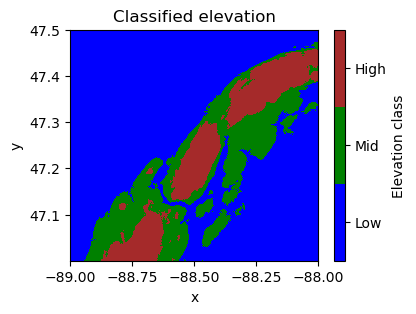

In [3]:
import numpy as np
import xarray as xr
import mapclassify

# read the elevation DataArray
elev = data['elevation']

# Flatten the raster data and store the original shape
raster_data_flattened = elev.values.flatten()
original_shape = elev.shape

# Create a mask for NaN values and remove NaNs for classification
nan_mask = np.isnan(raster_data_flattened)
raster_data_no_nan = raster_data_flattened[~nan_mask]

# Apply Natural Breaks classification with 3 classes
natural_breaks = mapclassify.NaturalBreaks(raster_data_no_nan, k=3)

# Get the classified bins
breaks = natural_breaks.bins
print('Natural break values: ',breaks)

# Classify the non-NaN raster values
classified_raster = np.digitize(raster_data_no_nan, bins=breaks)

# Create an array to hold the full reclassified data
reclassified_full_raster = np.full_like(raster_data_flattened, np.nan)

# Insert the classified data back, keeping NaNs in place
reclassified_full_raster[~nan_mask] = classified_raster

# Reshape the reclassified raster to its original shape
reclassified_full_raster = reclassified_full_raster.reshape(original_shape)

# Convert to xarray DataArray
reclassified_raster_nb = xr.DataArray(
    reclassified_full_raster,
    dims=elev.dims,
    coords=elev.coords,
    attrs=elev.attrs
)

# Plot the reclassified raster
plot = reclassified_raster_nb.plot(cmap=plt.matplotlib.colors.ListedColormap(['blue', 'green', 'brown']),figsize=(4,3))

# Set only the ticks [1, 2, 3] on the colorbar
colorbar = plot.colorbar
colorbar.set_ticks([.5, 1.5, 2.5])
colorbar.set_ticklabels(['Low', 'Mid', 'High'])  # Rename the labels
colorbar.set_label("Elevation class")

plt.title("Classified elevation")
plt.show()

## Slope analysis

**Slope analysis** is a key terrain analysis technique used in GIS to measure the steepness or incline of the terrain at any given point. It is calculated by examining the rate of change in elevation between neighboring pixels. Slope analysis helps identify areas with steep gradients, which is useful in applications like land-use planning, erosion risk assessment, hydrological modeling, and infrastructure development. The slope is typically expressed in degrees or as a percentage.

The slope at each point is derived by determining the rate of change in elevation between neighboring cells in the raster.

Step 1. **Gradient Calculation**: We use the elevation differences between adjacent cells in both the x (horizontal) and y (vertical) directions. The gradient represents how quickly elevation changes in these directions.
   
Step 2. **Slope Formula**: The slope is calculated by combining these gradients using the Pythagorean theorem:
$$
\text{slope} = \sqrt{\left(\frac{\Delta z}{\Delta x}\right)^2 + \left(\frac{\Delta z}{\Delta y}\right)^2}
$$

where Delta z  is the change in elevation, and Delta x and Delta y are the distances between the cells in the x and y directions.

Step 3. **Final Slope Values**: The result is often expressed in degrees or as a percentage, with steeper areas showing higher slope values. We use degrees here. 


In the following, we will use a DEM tile from the Texas hill country to demonstrate slope calculation.


EPSG:4326
Coordinate bounds: (-100.00013888888888, 29.999861111111116, -98.99986111111112, 31.00013888888889)
EPSG:32614


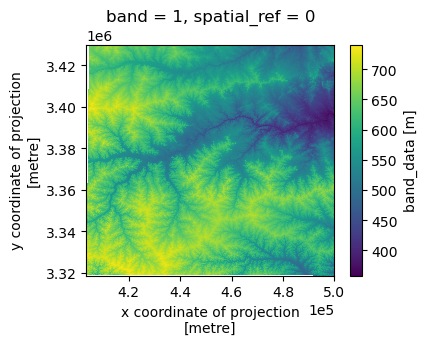

In [4]:
import rioxarray

data = xr.open_dataset('data/n30_w100_1arc_v3.tif', engine="rasterio")
print(data.rio.crs)

# print out lon/lat bounds
print("Coordinate bounds:", data.rio.bounds())

# This is an important step. The Dataset is reprojected to a projected CRS (in this case, UTM Zone 14N)
# Because slope must be calculated on metric units
data_utm = data.rio.reproject(dst_crs="EPSG:32614")
print(data_utm.rio.crs)

dem = data_utm['band_data'].squeeze(dim='band')
dem.plot(figsize=(4,3))

# use scientific notation for axis labels
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

In [5]:
# Calculate gradients in the x and y directions
dzdx = dem.differentiate(coord='x') # Gradient in the x direction
dzdy = dem.differentiate(coord='y') # Gradient in the y direction

# Calculate the slope (in degrees)
slope_radians = np.sqrt(dzdx**2 + dzdy**2)
slope = np.arctan(slope_radians) * (180 / np.pi)

# Update the attributes to reflect that this is a slope raster
slope.attrs['long_name'] = 'Slope'
slope.attrs['units'] = 'degrees'

print('minimum slope:', slope.min().item(), '; maximum slope:', slope.max().item())

minimum slope: 0.0 ; maximum slope: 43.22214889526367


Now let's plot our Slope raster. 

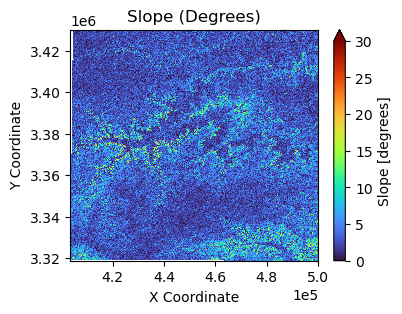

In [6]:
# Plot the slope raster
plt.figure(figsize=(4,3))
slope.plot(cmap='turbo',add_colorbar=True, vmin=0, vmax=30)
plt.title("Slope (Degrees)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
# use scientific notation for axis labels
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
plt.show()

## Raster-to-Raster Calculations

Raster-to-raster calculations involve performing mathematical or logical operations on two or more raster datasets to derive new information. Each raster grid cell is processed based on corresponding cells from the input rasters. This method is commonly used in geospatial analysis to perform tasks like:

- **Combining terrain attributes**: Slope, aspect, and DEM can be used to calculate terrain stability or hydrological indices.
- **Environmental modeling**: Calculating indices such as vegetation health (NDVI) using different raster bands.
- **Suitability analysis**: Combining different factors such as elevation and slope to determine land use or habitat suitability.

**Example: Peakness Index**
The idea is to create a "peakness" (or "mountainousness") index that highlights areas which are both high in elevation and steep.
- Because slope and elevation can have different ranges, we need to standardize or normalize them before combining. For instance, we can linearly stretch each raster to a 0–1 scale.
- Combine Slope and Elevation into a “Peakness” Index via a basic arithmetic expression, e.g.
    - Peakness = Slope_scaled + Elevation_scaled

Now let's write this in Python:

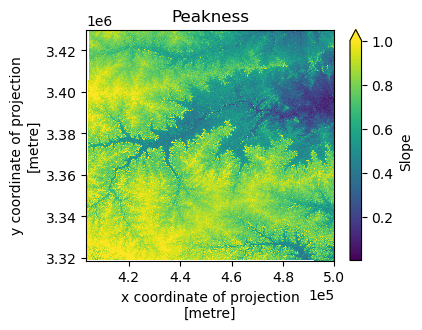

In [7]:
import numpy as np
import rioxarray as rxr

# Standardize Rasters
slope_scaled = (slope - slope.min().item())/(slope.max().item() - slope.min().item())
dem_scaled = (dem - dem.min().item())/(dem.max().item() - dem.min().item())

# Calculate peakness index
peakness = slope_scaled + dem_scaled

# Create a map
fig, ax = plt.subplots(1,1, figsize=(4,3))
peakness.plot(ax=ax, vmax=1, add_colorbar=True)
ax.set_title("Peakness")

# use scientific notation for axis labels
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

## Working with multi-band data
In GIS and remote sensing, multiband raster files are commonly used to store imagery, such as satellite images, where each band represents a different wavelength of the electromagnetic spectrum (e.g., red, green, blue, near-infrared). In such files, each pixel has multiple values corresponding to the reflectance in different bands.

In this section, we will explore how to load a multiband raster file, examine the individual bands, and visualize the data. This file consists of the R, G, B and NIR reflectances over a 1-deg x 1-deg region near New Orleans, downsampled to 120-m resolution from the original 30-m Landsat OLI L2 reflectance data.

In [8]:
import rioxarray

landsat = rioxarray.open_rasterio('data/landsat_rgbnir_cropped.tif')
landsat

<xarray.DataArray (band: 4, y: 934, x: 812)> Size: 6MB
[3033632 values with dtype=uint16]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 7kB 3.431e+06 3.431e+06 ... 3.319e+06 3.319e+06
  * x            (x) float64 6kB 3.071e+05 3.072e+05 ... 4.044e+05 4.045e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    _FillValue:     0
    scale_factor:   1.0
    add_offset:     0.0

Let’s have a closer look at the properties of the raster:

In [9]:
# Projection
landsat.rio.crs

CRS.from_epsg(32616)

In [10]:
# Dimensions
print(landsat.rio.width)
print(landsat.rio.height)

812
934


In [11]:
# Resolution
print(landsat.rio.resolution())

(120.03694581280787, -120.06423982869363)


In [12]:
# Number of bands
landsat.rio.count

4

Let's plot our raster:

(array([3.000000e+00, 1.122000e+03, 2.494908e+06, 1.001140e+05,
        2.615250e+05, 1.726790e+05, 2.574000e+03, 5.240000e+02,
        1.580000e+02, 2.500000e+01]),
 array([    0. ,  3755.3,  7510.6, 11265.9, 15021.2, 18776.5, 22531.8,
        26287.1, 30042.4, 33797.7, 37553. ]),
 <BarContainer object of 10 artists>)

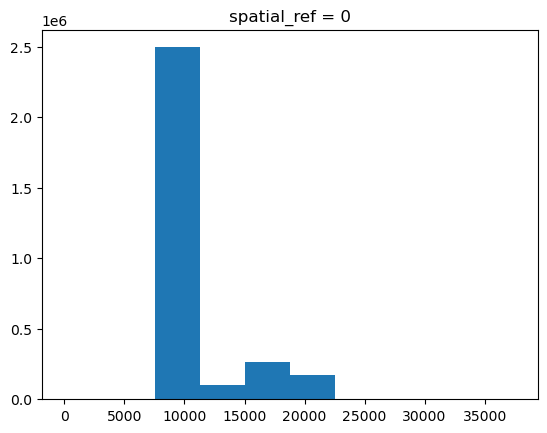

In [13]:
landsat.plot()

What just happened? The output is probably not what you expected.

When you try to plot a multiband raster directly using the `plot()` function, xarray interprets the data as a multi-dimensional array and creates a summary, such as a bar chart, to represent the entire dataset. This happens because xarray doesn't know you're working with geospatial raster data and tries to plot all bands together.

To correctly visualize the raster data, you need to plot individual bands or create an RGB composite. But before getting there, let's have a look at the metadata: 

In [14]:
# Print metadata and band information
print(landsat)

<xarray.DataArray (band: 4, y: 934, x: 812)> Size: 6MB
[3033632 values with dtype=uint16]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 7kB 3.431e+06 3.431e+06 ... 3.319e+06 3.319e+06
  * x            (x) float64 6kB 3.071e+05 3.072e+05 ... 4.044e+05 4.045e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    _FillValue:     0
    scale_factor:   1.0
    add_offset:     0.0


From this metadata, we learn that the raster file contains 4 bands, and the pixel values are stored as 16-bit uint (uint16) numbers. The coordinates provide the geospatial reference with `x` and `y` representing the spatial extent, while each `band` corresponds to a different spectral band. Additionally, the file has attributes such as _FillValue of 0, scale factor of 1.0, and no offset applied.

However, this brief metadata does not tell us which spectral band each raster band refers to. However, this is the kind of information that you should get from the data source. This file contains data from LandSat 9 band 2, 3, 4 and 5 (B, G, R, NIR) covering a region near New Orleans. Here are a table of all the bands of Landsat's Operational Land Imager 2 (OLI-2).

| **Band**   | **Description**                     | **Wavelength (µm)** |
|------------|-------------------------------------|---------------------|
| Band 1     | Visible Coastal Aerosol | 0.43 - 0.45 µm  |
| Band 2     | Blue | 0.450 - 0.51 µm    |
| Band 3     | Green| 0.53 - 0.59 µm    |
| Band 4     | Red  | 0.64 - 0.67 µm    |
| Band 5     | Near-Infrared       | 0.85 - 0.88 µm    |
| Band 6     | SWIR 1       | 1.57 - 1.65 µm    |
| Band 7     | SWIR 2       | 2.11 - 2.29 µm    |
| Band 8     | Panchromatic (PAN)  | 0.50 - 0.68 µm    |
| Band 9     | Cirrus      | 1.36 - 1.38 µm    |

Depending on our data processing needs, we can use this reference to select the relevant bands for tasks such as true color composites (using Bands 4, 3, and 2) or vegetation analysis (using Bands 5 and 4 for NDVI).

Let's start by accessing the red band. In rioxarray, an individual band can be accessed using the `sel()` method, where you specify the band number. According to the reference above, `band=3` retrieves the red band: 

In [15]:
# Access red band (band 3)
red = landsat.sel(band=3)

Let's see what happen now if we try to plot this specific band of the raster file:

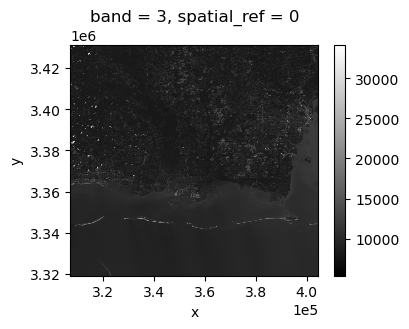

In [16]:
red.plot(figsize=(4,3),cmap='binary_r')
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

Let’s see how the R, G, B bands look like by placing them next to each other:

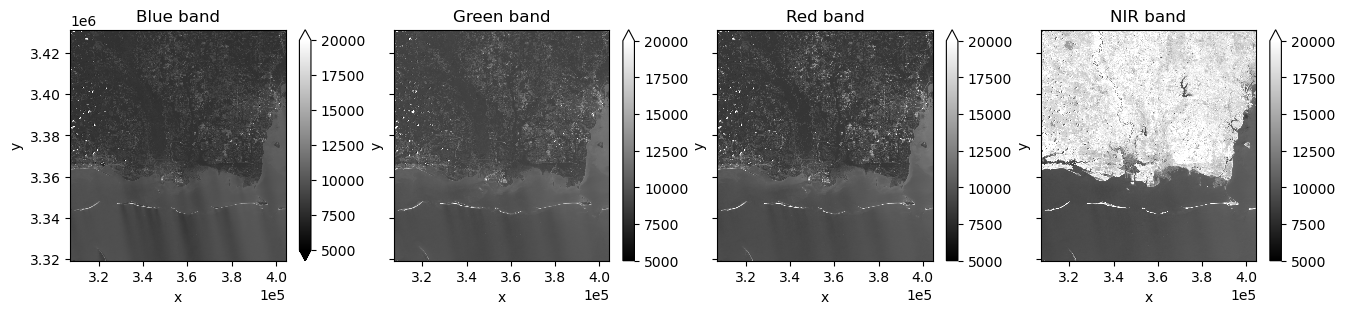

In [17]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, nrows=1, figsize=(16,3), sharey=True)

landsat.sel(band=1).plot(ax=ax1, cmap='binary_r',vmin=5000,vmax=20000)
landsat.sel(band=2).plot(ax=ax2, cmap='binary_r',vmin=5000,vmax=20000)
landsat.sel(band=3).plot(ax=ax3, cmap='binary_r',vmin=5000,vmax=20000)
landsat.sel(band=4).plot(ax=ax4, cmap='binary_r',vmin=5000,vmax=20000)

# Add titles
ax1.set_title("Blue band")
ax2.set_title("Green band")
ax3.set_title("Red band")
ax4.set_title("NIR band")   
ax1.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
ax2.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
ax3.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
ax4.ticklabel_format(style='sci', axis='both', scilimits=(0,0))


### Creating an RGB Composite

In remote sensing and GIS, creating an RGB composite is a common method for visualizing multiband satellite imagery in natural or false colors. By combining the red, green, and blue bands of a satellite image, we can generate a true-color image that resembles what the human eye would see, or we can create false-color composites for enhanced analysis (e.g., vegetation health, water bodies, etc.).

For Landsat imagery, the red, green, and blue bands correspond to:
- **Red**: Band 4
- **Green**: Band 3
- **Blue**: Band 2

We accomplish this by loading the individual red, green, and blue bands, stacking them together into an RGB image, and normalizing the values to be suitable for display. The Numpy's `np.dstack()` function stacks arrays along a new depth axis (3rd dimension), which is useful for combining multiple 2D arrays (e.g., raster bands) into a 3D RGB image ([NumPy *dstack* documentation](https://numpy.org/doc/stable/reference/generated/numpy.dstack.html)). 

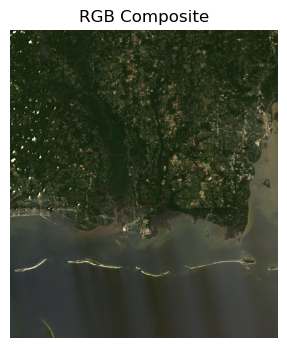

In [18]:
# Extract the red, green, and blue bands
red = landsat.sel(band=3)
green = landsat.sel(band=2)
blue = landsat.sel(band=1)

# L2 SR scale factor: values * 0.0000275 + (-0.2)
# The surface reflectance bands are stored as unsigned 16-bit integers to save disk space, not as actual reflectance values (which would be floats between 0 and 1). 
# The conversion formula is:
# Reflectance = DN × 0.0000275 + (−0.2)
# where DN is the digital number stored in the file.

red = red * 0.0000275 - 0.2
green = green * 0.0000275 - 0.2
blue = blue * 0.0000275 - 0.2

red = np.clip(red, 0, 0.3) / 0.3  # stretch for display
green = np.clip(green, 0, 0.3) / 0.3 
blue = np.clip(blue, 0, 0.3) / 0.3 

# Stack the bands together to create an RGB composite
rgb_image = np.dstack((red, green, blue))

# Plot the RGB composite image
plt.figure(figsize=(5,4))
plt.imshow(rgb_image)
plt.title("RGB Composite")
plt.axis('off')  # Hide the axis for better visualization
plt.show()

### False color composite
Following the previous example, it is easy to create false color composites with different band configurations. One typical method is to replace the blue band with near infra-red that can be used to detect vegetation easily where red color is emphasized.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05232500000000001..0.8327075000000002].


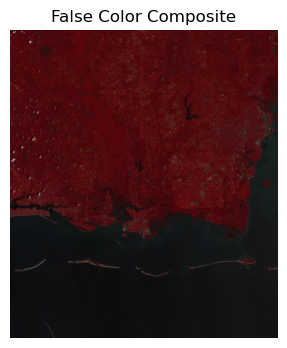

In [19]:
# Read the grid values into numpy arrays
nir = landsat.sel(band=4)
red = landsat.sel(band=3)
green = landsat.sel(band=2)

# Normalize the values using the function that we defined earlier
red = red * 0.0000275 - 0.2
green = green * 0.0000275 - 0.2
nir = nir * 0.0000275 - 0.2

# Create the composite by stacking
false_image = np.dstack((nir, red, green))

# Let's see how our color composite looks like
plt.figure(figsize=(5,4))
plt.imshow(false_image)
plt.title("False Color Composite")
plt.axis('off')  # Hide the axis for better visualization
plt.show()

## Raster map algebra

Conducting calculations between bands or raster is another common GIS task. Here, we will be calculating NDVI (Normalized difference vegetation index) based on the Landsat dataset. Conducting calculations with rioxarray is fairly straightforward if the extent etc. matches because the values of the rasters are stored as numpy arrays (similar to the columns stored in Geo/Pandas, i.e. Series). The definition of NDVI is:
$$
\text{NDVI} = \frac{NIR-RED}{NIR+RED}
$$

where NIR is the near-infrared band and Red is the red band. High NDVI values (towards 1) reflect a higher density of green vegetation, and low values (towards -1) reflect a lower density.

ndvi min: -176.37288135592172 ndvi max: 5.551452486459881


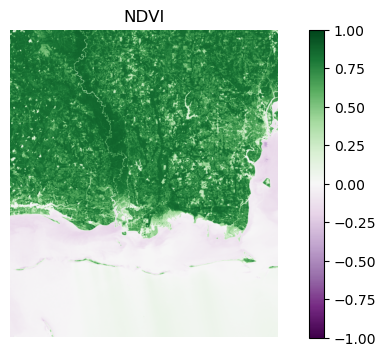

In [20]:
# Read red band
red = landsat.sel(band=3)

# Read NIR band
nir = landsat.sel(band=4)

red = red * 0.0000275 - 0.2
nir = nir * 0.0000275 - 0.2

# Calculate NDVI using numpy arrays
ndvi = (nir - red) / (nir + red)

print('ndvi min:', ndvi.min().item(),'ndvi max:', ndvi.max().item())

# Plot the NDVI
plt.figure(figsize=(8,4))
plt.imshow(ndvi, cmap='PRGn',vmin=-1,vmax=1)
# Add colorbar to show the index
plt.colorbar()
plt.title("NDVI")
plt.axis('off') 
plt.show()